## T1 - Project Introduction

This project focuses on analyzing a dataset of transactions. We must classify each transaction as fraud or not fraud using a ML model. 

This data set consists mostly of normal transactions, with only a minority being fraud, just like in the real world.

In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('../data/creditcard.csv')

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

## Q2 - How balanced are the fraud Classes?

Normal transactions make up 99.827% of all data, rest are fraud with 0.172%.

This proves a substantial class imbalance. The model can output 99.827% accuracy while catching 0% fraud, which is misleading.

For this reason we will use the recall metric - measuring how many of fraud we correctly identified.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
counts = df['Class'].value_counts()
total = counts.sum()
(counts / total) * 100

Class
0    99.827251
1     0.172749
Name: count, dtype: float64

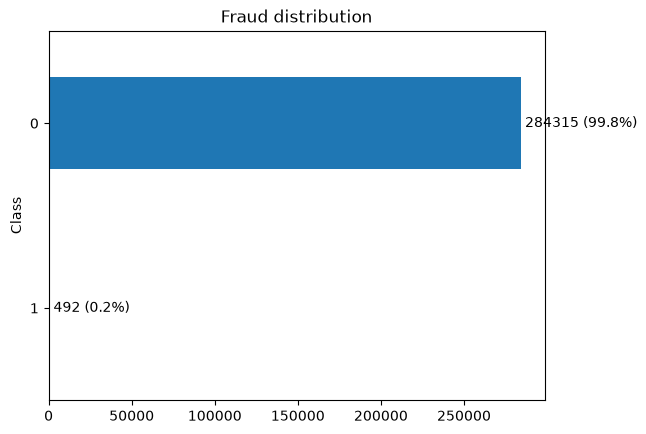

In [11]:
plt.title('Fraud distribution')
plt.xlabel('Count')

counts.sort_values().plot(kind='barh');
for i, (count, pct) in enumerate(zip(counts.sort_values(), counts.sort_values() / total * 100)):
    plt.text(count, i, f' {count} ({pct:.1f}%)', va='center')

In [12]:
from sklearn.metrics import accuracy_score, recall_score

## T2 - The Naive Accuracy Trap

Our dataset is heavily imbalanced, containing over 99% normal transactions and less than 1% fraudulent transactions. In situations like this, accuracy becomes a misleading metric because a model can achieve an extremely high accuracy score simply by predicting the majority class every time.

Our model achieved 99.82% accuracy, which initially appears excellent. However, this result is largely driven by the class distribution:

Normal transactions (Class 0): ~99.8%
Fraudulent transactions (Class 1): ~0.2%

The model classified nearly every transaction as normal. Since normal transactions dominate the dataset, most predictions were technically correct, resulting in a very high accuracy score.

The problem becomes clear when examining recall, which measures how many actual fraud cases were detected:

Recall = 0%
Fraud cases detected = 0

This means the model completely failed at its primary objective: identifying fraudulent transactions. Although it achieved 99.82% accuracy, it did not catch a single fraud case.

In [13]:
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import train_test_split
import numpy as np

zeros = np.zeros(len(df['Class']))

print(f"Accuracy: {accuracy_score(df['Class'], zeros)}")
print(f"Recall: {recall_score(df['Class'], zeros)}")

Accuracy: 0.9982725143693799
Recall: 0.0


## T3 - Data for training and testing

Test set must reflect reality. In production, fraud is 0.17% of transactions. If we evaluate the model on a 50/50 test set, our metrics are measuring performance on a fantasy dataset that doesn't exist. Our recall, precision, and F1 scores would be meaningless for real deployment.

The imbalance is preserved in both the train and test splits, this is what stratify is used for. We pass `y` to the method to tell the model we want to preserve the ratio of classes within `y`.

In [ ]:
# Splitting the data into inputs and the answer key
X = df.drop('Class', axis=1)
y = df['Class']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [16]:
print(f"y_train fraud ratio: {y_train.mean():.4%}")
print(f"y_test fraud ratio:  {y_test.mean():.4%}")

y_train fraud ratio: 0.1729%
y_test fraud ratio:  0.1720%


## T4 - Feature Scaling

The V1-V28 features are already scaled (PCA output), but Time and Amount are on their original scales. We use StandardScaler to normalize them. Important: fit the scaler on training data only, then transform both train and test. Fitting on test data would be data leakage - in production, we don't have future data to learn statistics from.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print(X_train['Time'].describe())

count    2.278450e+05
mean    -1.409578e-16
std      1.000002e+00
min     -1.998073e+00
25%     -8.561495e-01
50%     -2.122647e-01
75%      9.366285e-01
max      1.640549e+00
Name: Time, dtype: float64


## T5 - Naive Random Forest (no imbalance handling)

Train a Random Forest with default settings - no `class_weight` parameter. This is the same approach from Project 2 applied directly to imbalanced data.

The model will likely hit ~99.9% accuracy. But check the confusion matrix: how many fraud cases land in the bottom-left cell (predicted legitimate, actually fraud)? Those are missed fraudulent transactions - the ones that cost money.

A model that reports 99.9% accuracy while missing fraud isn't a fraud detector - it's a legitimate-traffic detector that occasionally catches fraud by accident.

Accuracy: 0.9996

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



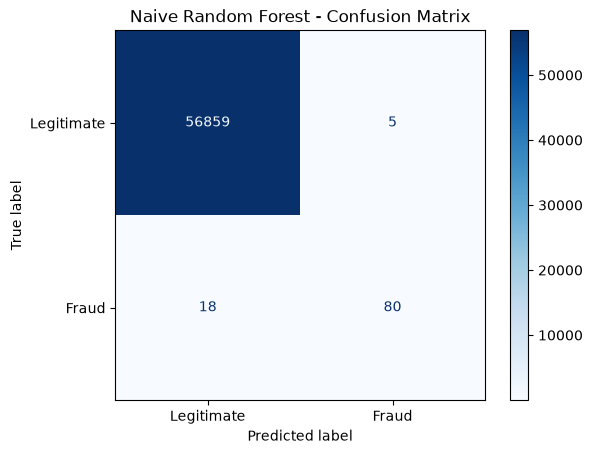

In [28]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

rf_naive = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_naive.fit(X_train, y_train)
y_pred_naive = rf_naive.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_naive):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_naive))

cm_naive = confusion_matrix(y_test, y_pred_naive)
ConfusionMatrixDisplay(cm_naive, display_labels=['Legitimate', 'Fraud']).plot(cmap='Blues')
plt.title('Naive Random Forest - Confusion Matrix')
plt.show()

## T6 - Balanced Random Forest

One parameter change: `class_weight='balanced'`. This tells sklearn to calculate a weight for each class using the formula: `n_samples / (n_classes * n_samples_for_class)`. With our ratio, each fraud sample gets treated as ~578x more important than a legitimate sample during training.

The model now pays a much heavier penalty for misclassifying fraud. Accuracy may drop slightly - that's acceptable. The question is: how many more fraud cases does it catch?

Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



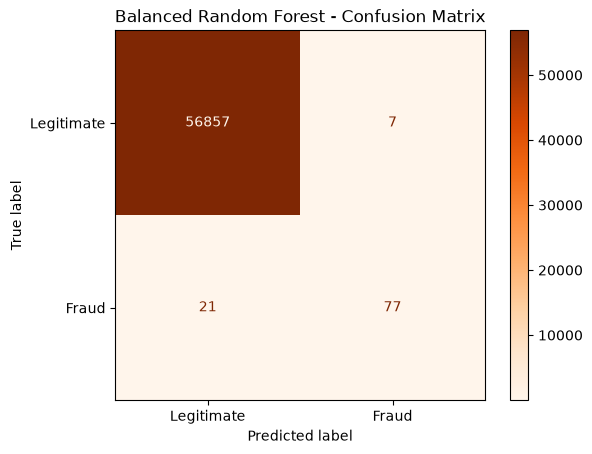

In [30]:
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
ConfusionMatrixDisplay(cm_balanced, display_labels=['Legitimate', 'Fraud']).plot(cmap='Oranges')
plt.title('Balanced Random Forest - Confusion Matrix')
plt.show()

## T7 - Side-by-Side Comparison + Financial Impact

Putting both confusion matrices next to each other makes the tradeoff visible at a glance. Then we translate missed fraud into euros - because in production, every false negative has a dollar amount attached to it.

In security terms: missed intrusions have a different cost than blocked legitimate traffic. The question "which error is worse?" always depends on context.

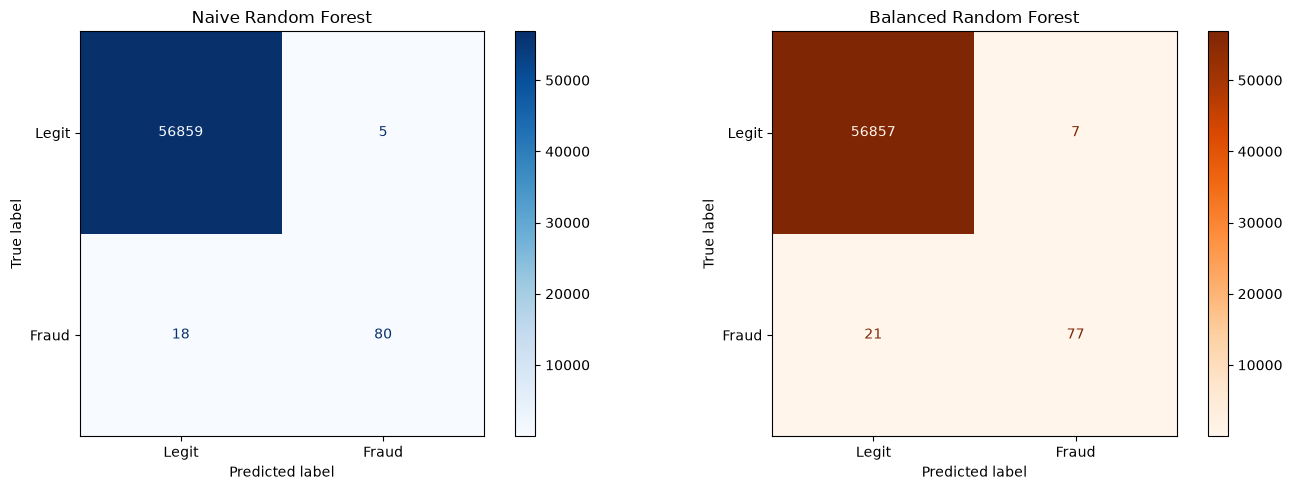

Average fraudulent transaction: EUR122.21
Naive model    - missed fraud cases: 18  (~EUR2,200)
Balanced model - missed fraud cases: 21  (~EUR2,566)


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_naive, display_labels=['Legit', 'Fraud']).plot(ax=axes[0], cmap='Blues')
ConfusionMatrixDisplay(cm_balanced, display_labels=['Legit', 'Fraud']).plot(ax=axes[1], cmap='Oranges')

axes[0].set_title('Naive Random Forest')
axes[1].set_title('Balanced Random Forest')
plt.tight_layout()
plt.show()

avg_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
missed_naive = cm_naive[1][0]
missed_balanced = cm_balanced[1][0]

print(f"Average fraudulent transaction: EUR{avg_fraud_amount:.2f}")
print(f"Naive model    - missed fraud cases: {missed_naive}  (~EUR{missed_naive * avg_fraud_amount:,.0f})")
print(f"Balanced model - missed fraud cases: {missed_balanced}  (~EUR{missed_balanced * avg_fraud_amount:,.0f})")

## T8 - ROC Curve and AUC

Until now we've been looking at hard 0/1 predictions - the model says "fraud" or "not fraud." But under the hood, the model actually produces a **confidence score** between 0 and 1 for each transaction via `predict_proba()`. A score of 0.9 means the model is 90% confident it's fraud. The default threshold of 0.5 converts these to hard predictions.

The **ROC curve** plots True Positive Rate (recall) vs False Positive Rate across all possible thresholds. Each point on the curve is a different threshold. Moving the threshold lower catches more fraud (higher TPR) but also triggers more false alarms (higher FPR).

**AUC** (Area Under the Curve) summarizes the entire curve as one number - 0.5 is random guessing, 1.0 is perfect.

Note: ROC AUC can look deceptively high even when the model struggles with extreme imbalance. This is because the x-axis (FPR) uses True Negatives, and when negatives massively outnumber positives, even a bad model scores well there. The PR curve in T9 is a more honest metric for this problem.

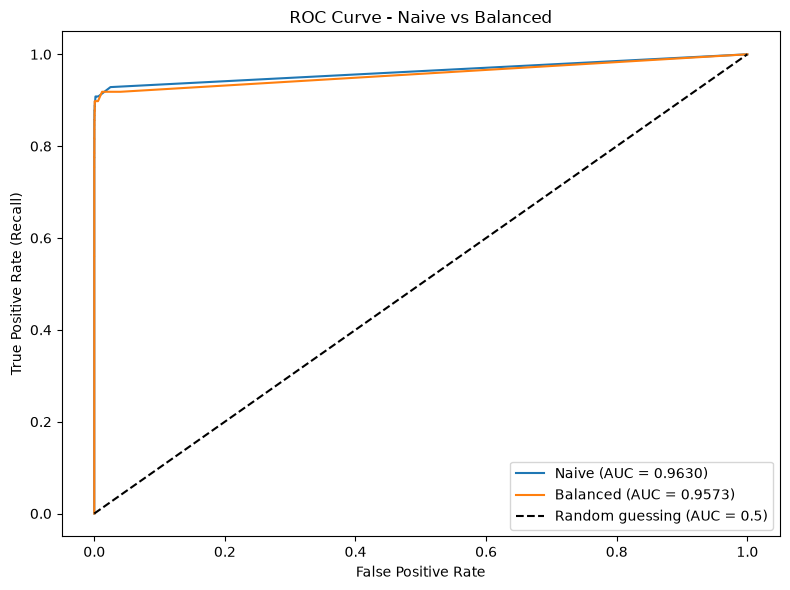

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

proba_naive = rf_naive.predict_proba(X_test)[:, 1]
proba_balanced = rf_balanced.predict_proba(X_test)[:, 1]

fpr_naive, tpr_naive, _ = roc_curve(y_test, proba_naive)
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, proba_balanced)

auc_naive = roc_auc_score(y_test, proba_naive)
auc_balanced = roc_auc_score(y_test, proba_balanced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_naive, tpr_naive, label=f'Naive (AUC = {auc_naive:.4f})')
plt.plot(fpr_balanced, tpr_balanced, label=f'Balanced (AUC = {auc_balanced:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Naive vs Balanced')
plt.legend()
plt.tight_layout()
plt.show()

## T9 - Precision-Recall Curve

The ROC curve is misleading when classes are extremely imbalanced. The x-axis uses False Positive Rate, which depends on True Negatives - and we have 56,000+ legitimate transactions in the test set. Even a mediocre model looks good because the denominator is huge.

The **Precision-Recall curve** fixes this by replacing FPR with Recall on the x-axis. Both metrics focus only on the minority class (fraud):
- **Recall** = TP / (TP + FN) - of actual fraud, how much did we catch?
- **Precision** = TP / (TP + FP) - of predicted fraud, how many were actually fraud?

As we lower the decision threshold (cast a wider net), Recall goes up but Precision goes down. This creates a real tradeoff curve that's honest about the imbalance.

For a **random model**, the PR curve is a flat line at the fraud rate (baseline ~ 0.0017). For a **good model**, the curve stays high above this baseline. Unlike ROC AUC, PR AUC directly reflects minority-class performance.

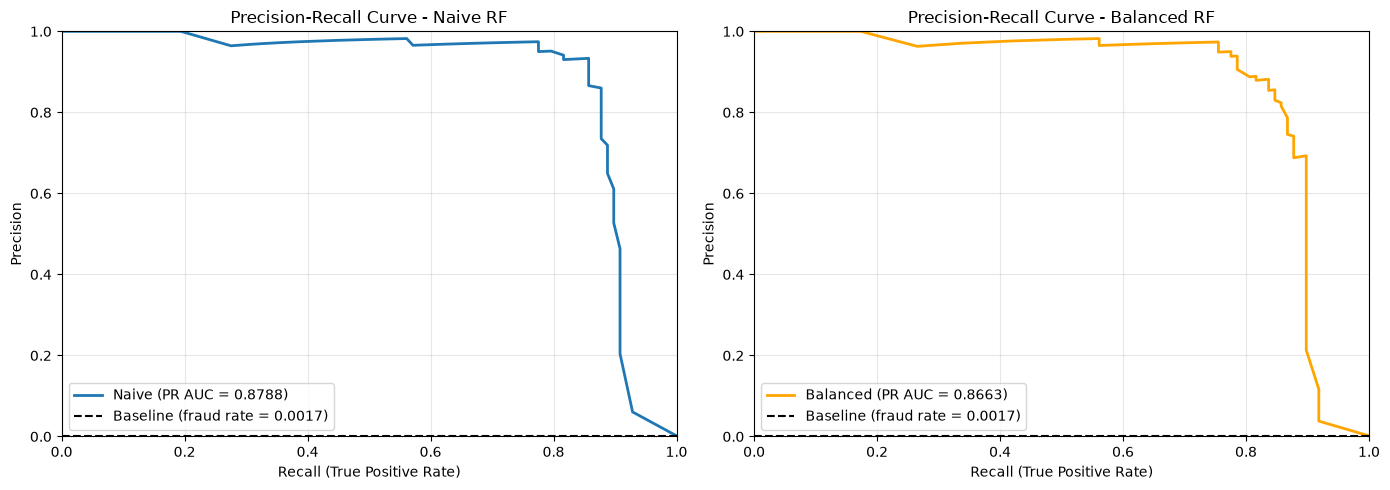

Naive RF    - PR AUC: 0.8788
Balanced RF - PR AUC: 0.8663

Fraud rate (baseline): 0.0017


In [33]:
from sklearn.metrics import precision_recall_curve, auc

precision_naive, recall_naive, _ = precision_recall_curve(y_test, proba_naive)
precision_balanced, recall_balanced, _ = precision_recall_curve(y_test, proba_balanced)

pr_auc_naive = auc(recall_naive, precision_naive)
pr_auc_balanced = auc(recall_balanced, precision_balanced)

fraud_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall_naive, precision_naive, label=f'Naive (PR AUC = {pr_auc_naive:.4f})', linewidth=2)
axes[0].axhline(y=fraud_rate, color='k', linestyle='--', label=f'Baseline (fraud rate = {fraud_rate:.4f})')
axes[0].set_xlabel('Recall (True Positive Rate)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Naive RF')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_balanced, precision_balanced, label=f'Balanced (PR AUC = {pr_auc_balanced:.4f})', linewidth=2, color='orange')
axes[1].axhline(y=fraud_rate, color='k', linestyle='--', label=f'Baseline (fraud rate = {fraud_rate:.4f})')
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Balanced RF')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Naive RF    - PR AUC: {pr_auc_naive:.4f}")
print(f"Balanced RF - PR AUC: {pr_auc_balanced:.4f}")
print(f"\nFraud rate (baseline): {fraud_rate:.4f}")

## T10 - Threshold Tuning with F-beta Score

The default threshold of 0.5 treats precision and recall equally. In fraud detection, missed fraud (false negative) is far more costly than a false alarm (false positive). We need a threshold that favors recall.

**F1 score** is the harmonic mean of precision and recall - it treats both equally. **F-beta score** generalizes this: when beta > 1, recall is weighted more heavily. With **beta=2 (F2 score)**, recall is weighted **4x more** than precision.

The approach:
1. Compute F2 score at every possible threshold (using the precision/recall arrays from T9)
2. Find the threshold that maximizes F2
3. Apply that threshold to get final predictions and evaluate with a confusion matrix

This is the deployment decision: where on the Precision-Recall curve should this model operate?

Best threshold:  0.2900
Best F2 score:   0.8502
At this point:   Precision = 0.8235, Recall = 0.8571

Default threshold (0.5) for comparison:
F2 score at 0.5: 0.8071


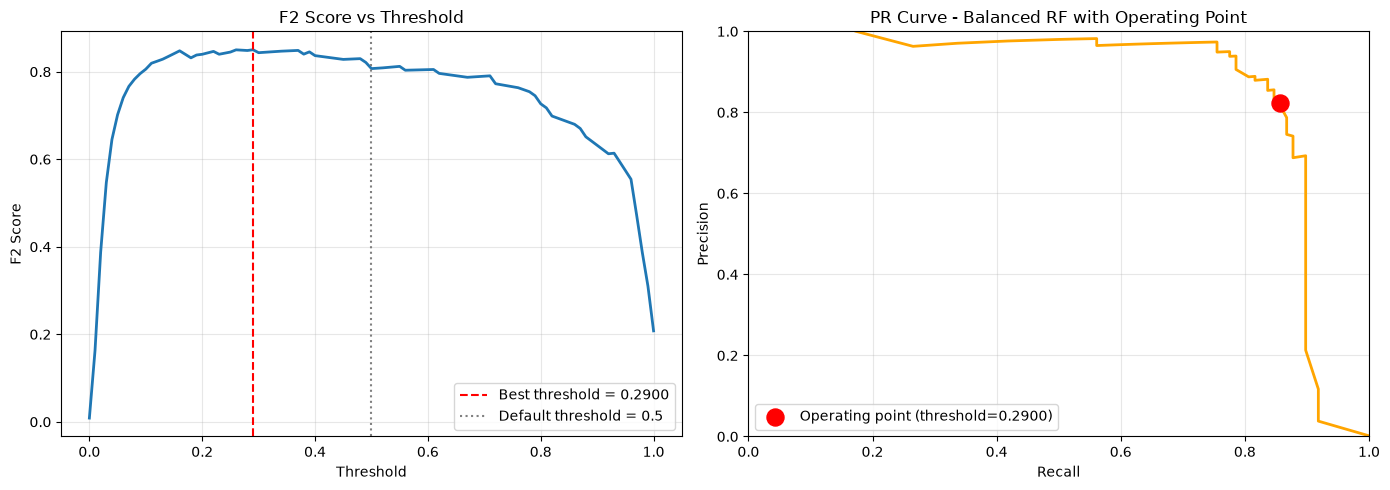

In [27]:
from sklearn.metrics import fbeta_score

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, proba_balanced)

# precision_recall_curve returns arrays where precision/recall have one extra element
precision_arr = precision_arr[:-1]
recall_arr = recall_arr[:-1]

beta = 2
f2_scores = ((1 + beta**2) * precision_arr * recall_arr) / ((beta**2 * precision_arr) + recall_arr)

best_idx = np.argmax(f2_scores)
best_threshold = thresholds_arr[best_idx]
best_f2 = f2_scores[best_idx]
best_precision = precision_arr[best_idx]
best_recall = recall_arr[best_idx]

print(f"Best threshold:  {best_threshold:.4f}")
print(f"Best F2 score:   {best_f2:.4f}")
print(f"At this point:   Precision = {best_precision:.4f}, Recall = {best_recall:.4f}")
print(f"\nDefault threshold (0.5) for comparison:")

default_pred = (proba_balanced >= 0.5).astype(int)
default_f2 = fbeta_score(y_test, default_pred, beta=2)
print(f"F2 score at 0.5: {default_f2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_arr, f2_scores, linewidth=2)
axes[0].axvline(x=best_threshold, color='r', linestyle='--', label=f'Best threshold = {best_threshold:.4f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Default threshold = 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F2 Score')
axes[0].set_title('F2 Score vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_arr, precision_arr, linewidth=2, color='orange')
axes[1].scatter(best_recall, best_precision, color='red', s=150, zorder=5, label=f'Operating point (threshold={best_threshold:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve - Balanced RF with Operating Point')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Tuned threshold: 0.2900

Classification Report (tuned threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.86      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



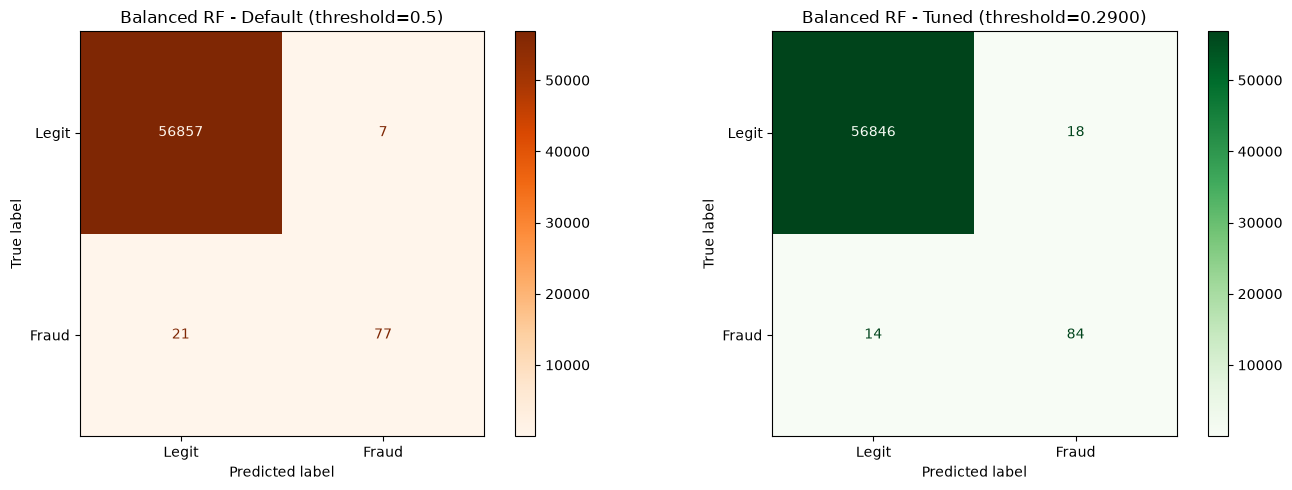


Default (0.5):  missed 21 fraud cases, 7 false alarms
Tuned (0.2900): missed 14 fraud cases, 18 false alarms

Fraud cases saved by tuning: 7
Extra false alarms from tuning: 11
Estimated savings: ~EUR855


In [26]:
y_pred_tuned = (proba_balanced >= best_threshold).astype(int)

print(f"Tuned threshold: {best_threshold:.4f}")
print(f"\nClassification Report (tuned threshold):")
print(classification_report(y_test, y_pred_tuned))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_default = confusion_matrix(y_test, y_pred_balanced)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

ConfusionMatrixDisplay(cm_default, display_labels=['Legit', 'Fraud']).plot(ax=axes[0], cmap='Oranges')
ConfusionMatrixDisplay(cm_tuned, display_labels=['Legit', 'Fraud']).plot(ax=axes[1], cmap='Greens')

axes[0].set_title('Balanced RF - Default (threshold=0.5)')
axes[1].set_title(f'Balanced RF - Tuned (threshold={best_threshold:.4f})')
plt.tight_layout()
plt.show()

missed_default = cm_default[1][0]
missed_tuned = cm_tuned[1][0]
false_alarms_default = cm_default[0][1]
false_alarms_tuned = cm_tuned[0][1]

print(f"\nDefault (0.5):  missed {missed_default} fraud cases, {false_alarms_default} false alarms")
print(f"Tuned ({best_threshold:.4f}): missed {missed_tuned} fraud cases, {false_alarms_tuned} false alarms")
print(f"\nFraud cases saved by tuning: {missed_default - missed_tuned}")
print(f"Extra false alarms from tuning: {false_alarms_tuned - false_alarms_default}")
print(f"Estimated savings: ~EUR{(missed_default - missed_tuned) * avg_fraud_amount:,.0f}")